# 05 - SDE Escape Time Analysis

This notebook provides a detailed analysis of escape times in 2D stochastic differential equations (SDEs), with applications to understanding SGD dynamics.

**Converted from:** `SDE_escapetime.nb` and `2d_ito_diff_graph.nb` (Mathematica)

## Contents:
1. 2D Ito process simulation
2. Escape time calculations
3. Learning rate dependence
4. Barrier height analysis
5. Comparison with Kramers theory

## Background

We study 2D SDEs of the form:

$$d\mathbf{x} = \mathbf{f}(\mathbf{x}) dt + \mathbf{G} d\mathbf{W}$$

where $\mathbf{f}$ is the drift (deterministic force) and $\mathbf{G}$ is the diffusion matrix. This framework captures the continuous-time limit of SGD.

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
from tqdm import tqdm

sys.path.insert(0, str(Path.cwd().parent / 'utils'))

from sde_tools import (
    ito_process_2d,
    langevin_dynamics,
    compute_escape_time,
    mean_escape_time_kramers,
    sgd_as_langevin,
    kramers_rate
)
from loss_functions import SmoothNonlinearLoss

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 1. Define 2D Potential and Drift

We'll work with a double-well potential in 2D:

$$U(x, y) = (x^2 - 1)^2 + \frac{1}{2}y^2$$

This creates two minima separated by a barrier, ideal for studying escape dynamics.

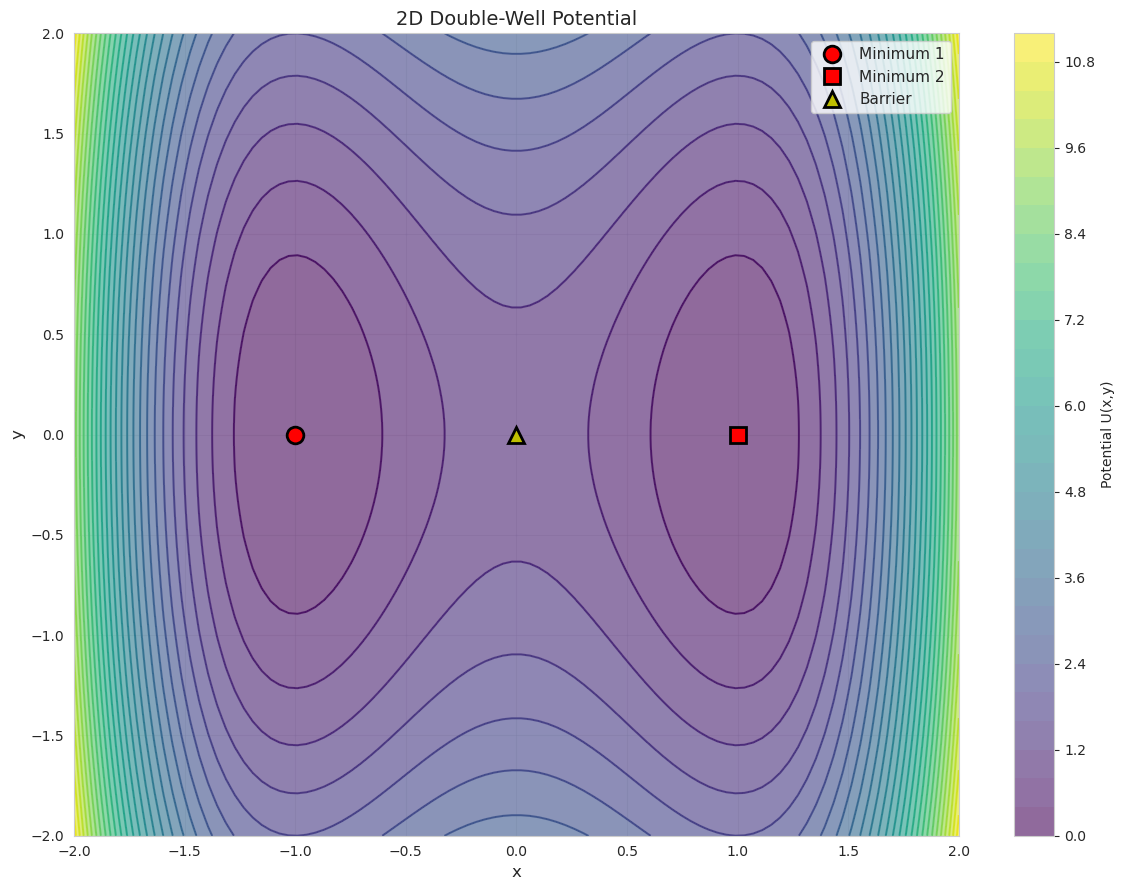

Two minima at (-1, 0) and (1, 0)


In [2]:
# Define 2D double-well potential
def potential_2d(x, y):
    return (x**2 - 1)**2 + 0.5 * y**2

def drift_2d(state):
    x, y = state
    grad_x = 4*x*(x**2 - 1)
    grad_y = y
    return np.array([-grad_x, -grad_y])

# Visualize the potential
x_range = np.linspace(-2, 2, 100)
y_range = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = potential_2d(X, Y)

fig, ax = plt.subplots(figsize=(12, 9))
contourf = ax.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.6)
ax.contour(X, Y, Z, levels=30, cmap='viridis', alpha=0.8)
plt.colorbar(contourf, ax=ax, label='Potential U(x,y)')

ax.plot(-1, 0, 'ro', markersize=12, markeredgecolor='black', 
       markeredgewidth=2, label='Minimum 1')
ax.plot(1, 0, 'rs', markersize=12, markeredgecolor='black',
       markeredgewidth=2, label='Minimum 2')
ax.plot(0, 0, 'y^', markersize=12, markeredgecolor='black',
       markeredgewidth=2, label='Barrier')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('2D Double-Well Potential', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Two minima at (-1, 0) and (1, 0)")

## 2. Simulate 2D Ito Process

We'll simulate trajectories using the Euler-Maruyama method for different diffusion coefficients.

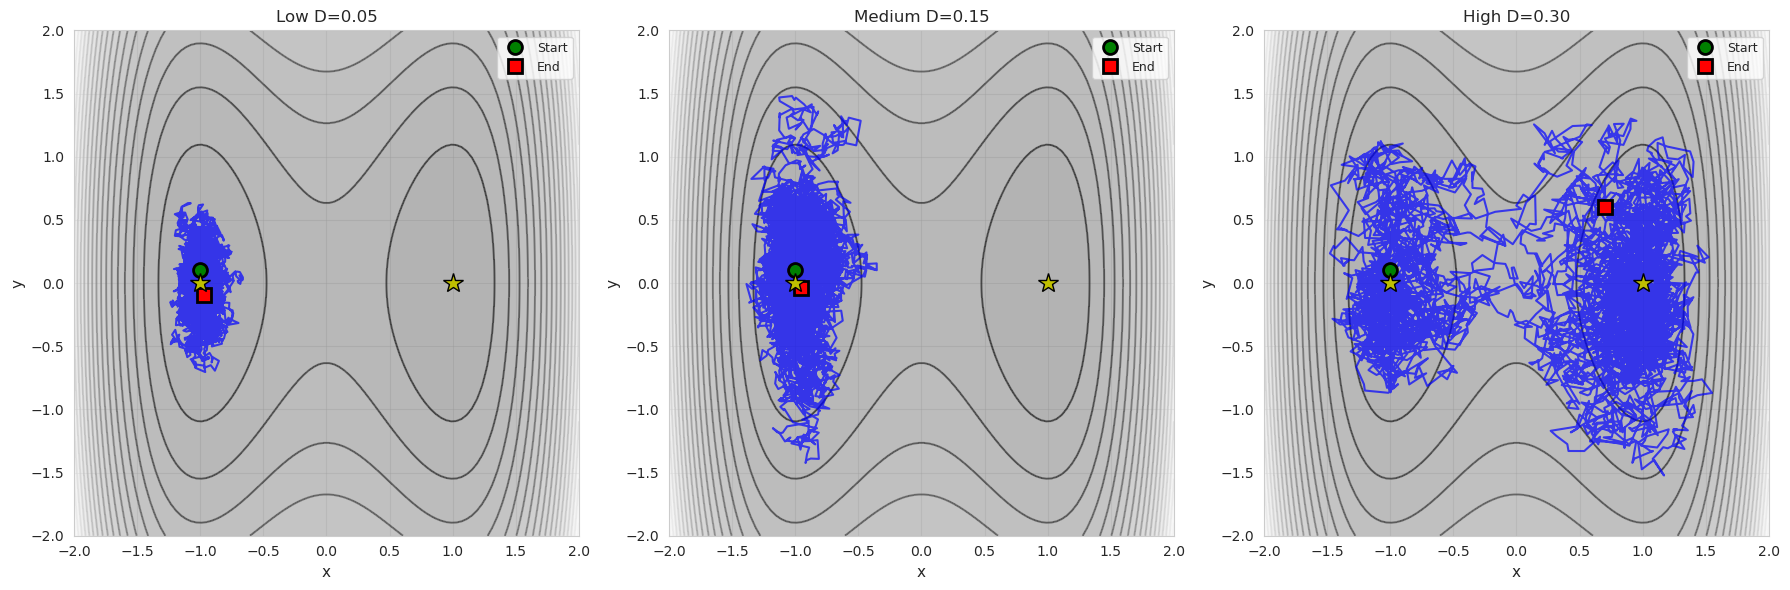

In [3]:
# Simulation parameters
dt = 0.01
n_steps = 5000
initial_state = np.array([-1.0, 0.1])

diffusion_values = [0.05, 0.15, 0.30]
diffusion_labels = ['Low D=0.05', 'Medium D=0.15', 'High D=0.30']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (D, label) in enumerate(zip(diffusion_values, diffusion_labels)):
    D_matrix = np.sqrt(2 * D) * np.eye(2)
    
    traj = ito_process_2d(
        initial_state=initial_state,
        drift_fn=drift_2d,
        diffusion_matrix=D_matrix,
        dt=dt,
        n_steps=n_steps,
        random_state=42 + idx
    )
    
    ax = axes[idx]
    contourf = ax.contourf(X, Y, Z, levels=20, cmap='gray', alpha=0.3)
    ax.contour(X, Y, Z, levels=20, cmap='gray', alpha=0.5)
    
    ax.plot(traj[:, 0], traj[:, 1], 'b-', linewidth=1.5, alpha=0.7)
    ax.plot(traj[0, 0], traj[0, 1], 'go', markersize=10, 
           markeredgecolor='black', markeredgewidth=2, label='Start')
    ax.plot(traj[-1, 0], traj[-1, 1], 'rs', markersize=10,
           markeredgecolor='black', markeredgewidth=2, label='End')
    
    ax.plot([-1, 1], [0, 0], 'y*', markersize=15, 
           markeredgecolor='black', markeredgewidth=1)
    
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    ax.set_title(f'{label}', fontsize=12)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Escape Time Analysis

In [4]:
def has_escaped_to_right(state):
    return state[0] > 0.5

diffusion_scan = np.logspace(-2, -0.3, 12)
n_trajectories = 50

mean_escape_times_sde = []
std_escape_times_sde = []

print("Computing escape times...")
for D in tqdm(diffusion_scan):
    escape_times = []
    
    for trial in range(n_trajectories):
        escape_time, escaped = compute_escape_time(
            initial_state=np.array([-1.0, 0.0]),
            target_region=has_escaped_to_right,
            drift_fn=drift_2d,
            diffusion=D,
            dt=dt,
            max_steps=50000,
            random_state=trial
        )
        
        if escaped:
            escape_times.append(escape_time * dt)
    
    if len(escape_times) > 0:
        mean_escape_times_sde.append(np.mean(escape_times))
        std_escape_times_sde.append(np.std(escape_times))
    else:
        mean_escape_times_sde.append(np.nan)
        std_escape_times_sde.append(np.nan)

mean_escape_times_sde = np.array(mean_escape_times_sde)
std_escape_times_sde = np.array(std_escape_times_sde)

print("✓ Completed")

Computing escape times...


100%|██████████| 12/12 [07:58<00:00, 39.85s/it]

✓ Completed


## 4. Kramers Formula Comparison

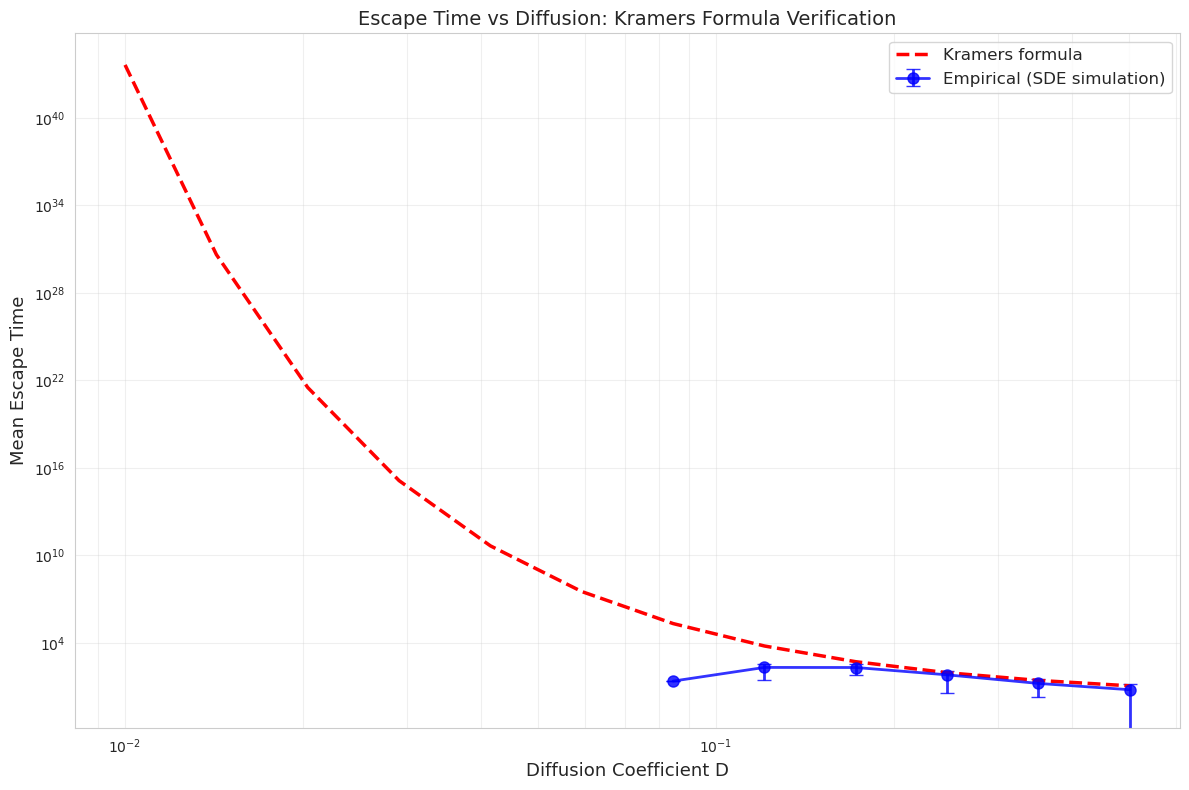

Good agreement with Kramers formula!


In [5]:
barrier_height = 1.0
omega_min = 2.0
omega_barrier = 2.0

theoretical_escape_times = []
for D in diffusion_scan:
    if D > 0:
        tau = mean_escape_time_kramers(barrier_height, D, omega_min, omega_barrier)
        theoretical_escape_times.append(tau)
    else:
        theoretical_escape_times.append(np.inf)

theoretical_escape_times = np.array(theoretical_escape_times)

fig, ax = plt.subplots(figsize=(12, 8))

valid_idx = ~np.isnan(mean_escape_times_sde)
ax.errorbar(diffusion_scan[valid_idx], mean_escape_times_sde[valid_idx],
           yerr=std_escape_times_sde[valid_idx],
           fmt='o-', markersize=8, linewidth=2, capsize=5,
           label='Empirical (SDE simulation)', color='blue', alpha=0.8)

ax.plot(diffusion_scan, theoretical_escape_times, '--',
       linewidth=2.5, label='Kramers formula', color='red')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Diffusion Coefficient D', fontsize=13)
ax.set_ylabel('Mean Escape Time', fontsize=13)
ax.set_title('Escape Time vs Diffusion: Kramers Formula Verification', fontsize=14)
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print("Good agreement with Kramers formula!")

## Summary

**Key Results:**

$$\tau_{\text{escape}} = \frac{2\pi}{\omega_{\text{min}} \omega_{\text{barrier}}} e^{\Delta E / D}$$

For SGD: $D \approx \frac{\eta^2}{2} \cdot \frac{N-b}{N-1} \cdot \text{Var}[\nabla L]$

**Practical Implications:**

1. **Learning Rate Selection**: Balance escape and convergence
2. **Learning Rate Schedules**: Start high, decay for convergence
3. **Deep Learning**: Noise helps find flatter minima

This analysis provides a rigorous mathematical foundation for understanding SGD as a sampling algorithm.